In [1]:
%load_ext autoreload
%autoreload 2

# 4D SfM Pipeline

Processes one new day at a time through the full 4D SfM workflow:

1. **Multi-temporal BA** — reference cameras fixed (0.001), new day cameras loose (0.5 m / 5°)
2. **Single-day re-run** — IOP fixed from step 1, EOP loose, generates point cloud
3. **Co-registration** — ASP `pc_align` against the fixed initial reference cloud
4. **Apply transform** — transform applied to single-day camera positions
5. **Update Metashape** — co-registered positions imported into the single-day `.psx`
6. **Validation** — rebuild point cloud from co-registered cameras, M3C2 against Step 3b stable TBA (near-zero → transform propagated correctly)
7. **Update registry** — validated EOP + IOP path appended to `reference_registry.csv`

In [1]:
import os
os.environ["AGISOFT_LICENSE_PATH"] = "/home/asus/.config/Agisoft/license.lic"

import Metashape
import cntp
import sys
sys.path.insert(0, str(__import__('pathlib').Path('../../contributors/umayr').resolve()))
import tools

from pathlib import Path
import numpy as np
import pandas as pd

from cntp.metashape import (
    discover_images,
    run_multitemporal_ba,
    run_single_day_fixed_iop,
    update_metashape_cameras_after_transform,
    update_registry,
    _utm_epsg,
)
from tools import (
    pc_align_p2p_sp2p,
    extract_stable_reference,
    evaluate_coreg,
    apply_coreg_to_cameras_ecef,
    _read_asp_transform,
)

## Configuration
Set all paths and parameters here. Everything below runs without further edits.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────
base_dir     = Path("/mnt/g/2023_11_Nepal/2023_Changri")
tlcam_dir    = base_dir / "TLCAM"
output_dir   = base_dir

# Fixed initial reference point cloud — never changes across all days
ref_cloud    = base_dir / "Ref_PC" / "Reference_UAV_TLC_PCS.laz"

# Glacier mask shapefile (UTM) — used for stable terrain filtering in Stage 3
glacier_mask = base_dir / "glaciermask_new" / "glacier_mask_pcs.shp"

# Registry — must already exist (run bootstrap_registry.ipynb first)
registry_csv = output_dir / "output_new" / "reference_registry.csv"

# ── Date to process ───────────────────────────────────────────────────────
new_date = "2023-12-15"   # <-- change this for each new day

# ── BA parameters ─────────────────────────────────────────────────────────
match_downscale = 0    # 0, 1, 2, 3 = resolution
depth_downscale = 2    # 0, 1, 2, 3 = resolution

# Accuracy for new-day cameras in multi-temporal BA and single-day re-run
loc_acc_new = (0.5, 0.5, 0.5)   # metres
rot_acc_new = (5.0, 5.0, 5.0)   # degrees

# Co-registration parameters
ref_downsample  = 0.4
tba_downsample  = 1.0
p2p_max_disp    = 10
sp2p_max_disp   = 5
m_sp2p_max_disp = 2

# ── Co-registration coordinate space ──────────────────────────────────────
# True  → clouds converted UTM→ECEF before pc_align; transform applied
#          to cameras as WGS84→ECEF→T→ECEF→WGS84
# False → clouds passed to pc_align in UTM; transform applied to cameras
#          as WGS84→UTM→T→UTM→WGS84
use_ecef = True

# ── Derived from registry ─────────────────────────────────────────────────
df_reg   = pd.read_csv(registry_csv)
utm_epsg = _utm_epsg(df_reg["lon"].mean())
print(f"UTM EPSG         : {utm_epsg}")
print(f"Registry entries : {df_reg['date'].nunique()} days, {len(df_reg)} images total")
print(f"Co-reg mode      : {'ECEF' if use_ecef else 'UTM'}")

UTM EPSG         : 32645
Registry entries : 1 days, 20 images total
Co-reg mode      : ECEF


## Discover images for the new day

In [3]:
by_date     = discover_images(tlcam_dir)
date_images = by_date.get(new_date)

if date_images is None:
    raise ValueError(f"No images found for {new_date} under {tlcam_dir}")

for cam, paths in date_images.items():
    print(f"  {cam} : {len(paths)} images")

  C1 : 9 images
  C2 : 9 images
  C3 : 9 images
  C4 : 8 images
  C5 : 9 images


## Step 1 — Multi-temporal bundle adjustment

- All reference cameras (from registry) held fixed at accuracy **0.001**
- New-day cameras initialised with mean EOP of the last registry day per camera group, accuracy **0.5 m / 5°**
- Each reference day gets its own fixed sensor per camera (preserves per-day IOP)
- New-day sensors: IOP floating, initialised from last registry day's refined calibration

Outputs → `output_new/YYYY-MM-DD/4D_SfM/`

In [5]:
cameras_4dsfm_csv, calib_4dsfm_dir = run_multitemporal_ba(
    date                   = new_date,
    date_images            = date_images,
    reference_registry_csv = registry_csv,
    output_dir             = output_dir,
    utm_epsg               = utm_epsg,
    match_downscale        = match_downscale,
    loc_acc_new            = loc_acc_new,
    rot_acc_new            = rot_acc_new,
)

print(f"\nCameras CSV : {cameras_4dsfm_csv}")
print(f"Calib dir   : {calib_4dsfm_dir}")


  4D SfM BA : 2023-12-15   (44 new images, 20 reference images)
SaveProject: path = /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/4D_SfM/2023-12-15_4DSfM.psx
saved project in 0.08371 sec
LoadProject: path = /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/4D_SfM/2023-12-15_4DSfM.psx
loaded project in 0.026518 sec
AddPhotos
AddPhotos
  Added 20 reference + 44 new-day images
  Sensors : 1 ref days × 5 cameras (fixed IOP) + 5 new (floating IOP)
  Reference cameras (tight 0.001) : 20/20
  New-day cameras  (loose 0.5 m / 5.0°) : 44/44
  Matching photos ...
MatchPhotos: downscale = 0, generic_preselection = on, reference_preselection = on, filter_mask = off, mask_tiepoints = on, filter_stationary_points = on, keypoint_limit = 40000, keypoint_limit_per_mpx = 1000, tiepoint_limit = 4000, guided_matching = off, exclude_corners = off
saved matching data in 0.015634 sec
saved object list in 0.005169 sec
scheduled 4 keypoint detection groups
saved keypoint partition in 0.005066 s

Can't load OpenCL library
failed to enable cpu vulkan support (/home/asus/miniconda3/envs/cntp/bin/lib dir not exists)


Found 1 GPUs in 1.63604 sec (CUDA: 1.3482 sec, OpenCL: 0.002084 sec, Vulkan: 0.285678 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
  got device properties in 0.000574 sec, free memory in 0.538257 sec
[GPU] processing 6512x4884 image using 3256x4884 tiles
[GPU] photo 0: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 20: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 24: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 28: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 7: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 32: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 36: 40000 points
[GPU] processing 6512x4884 image

Can't load OpenCL library


[GPU] processing 6512x4884 image using 3256x4884 tiles
[GPU] photo 1: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 21: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 25: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 4: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 29: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 33: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 37: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 11: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 41: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 45: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 14: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 49: 40000 p

...

810795 matches found in 0.625714 sec
matches combined in 0.057785 sec
filtered 106401 out of 445782 matches (23.8684%) in 0.127251 sec
saved matches in 0.052039 sec
loaded matching data in 0.002577 sec
loaded matching partition in 0.003171 sec
loaded object list in 0.002577 sec
loaded matches in 0.019352 sec
1791 pairs selected in 0.000329 sec
setting point indices... 17788 done in 0.002219 sec
setting point indices... 15815 done in 0.00156 sec
setting point indices... 15659 done in 0.001667 sec
150 skeletal pairs selected in 0.012465 sec
groups: 75 75
90 of 64 used (140.625%)
scheduled 2 keypoint matching groups
saved matching partition in 0.012686 sec
loaded object list in 0.0022 sec
loaded matching partition in 0.00387 sec
loaded keypoint partition in 0.003124 sec
loaded matching data in 0.001951 sec
loaded keypoints in 1.01784 sec


Can't load OpenCL library


Found 1 GPUs in 0.000651 sec (CUDA: 2.3e-05 sec, OpenCL: 0.000334 sec, Vulkan: 0.000263 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
644278 matches found in 7.05515 sec
matches combined in 0.055503 sec
filtered 54200 out of 336977 matches (16.0842%) in 0.23283 sec
saved matches in 0.074697 sec
loaded object list in 0.002922 sec
loaded matching partition in 0.003414 sec
loaded keypoint partition in 0.003522 sec
loaded matching data in 0.002715 sec
loaded keypoints in 0.837776 sec
Found 1 GPUs in 0.000811 sec (CUDA: 2.7e-05 sec, OpenCL: 0.000432 sec, Vulkan: 0.00032 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]


Can't load OpenCL library


873851 matches found in 7.01074 sec
matches combined in 0.082608 sec
filtered 49418 out of 448834 matches (11.0103%) in 0.299658 sec
saved matches in 0.081259 sec
loaded matching data in 0.003017 sec
loaded object list in 0.002248 sec
loaded matching partition in 0.003625 sec
loaded keypoint partition in 0.003721 sec
loaded matches in 0.035524 sec
setting point indices... 206695 done in 0.043503 sec
generated 206695 tie points, 3.75954 average projections
removed 13884 multiple indices
removed 201 tracks
removing stationary tracks...
removed 170314 tracks
selected 36180 tracks out of 36180 in 0.002609 sec
loaded keypoint partition in 0.003171 sec
loaded matching partition in 0.00327 sec
loaded matching partition in 0.003003 sec
  Aligning cameras ...
AlignCameras: adaptive_fitting = off
processing matches... done in 0.010406 sec
selecting camera groups... 
groups: 64
n groups: 1, total: 64, minmax: [64, 64]
done in 0.007546 sec
scheduled 1 alignment groups
saved camera partition in 0.0

## Step 2 — Single-day re-run with fixed IOP

- IOP fixed from Step 1 (`adjusted_calib_4DSfM/`)
- EOP loose (same accuracy as Step 1: 0.5 m / 5°), priors from `cameras_4DSfM.csv`
- Generates the point cloud for co-registration

Outputs → `output_new/YYYY-MM-DD/single_day/`

In [6]:
laz_path, cameras_single_csv = run_single_day_fixed_iop(
    date            = new_date,
    date_images     = date_images,
    calib_dir       = calib_4dsfm_dir,
    cameras_csv     = cameras_4dsfm_csv,
    output_dir      = output_dir,
    utm_epsg        = utm_epsg,
    match_downscale = match_downscale,
    depth_downscale = depth_downscale,
    loc_acc         = loc_acc_new,
    rot_acc         = rot_acc_new,
)

print(f"\nPoint cloud : {laz_path}")
print(f"Cameras CSV : {cameras_single_csv}")


  Single-day BA (fixed IOP) : 2023-12-15   (44 images)
SaveProject: path = /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/single_day/2023-12-15.psx
saved project in 0.05766 sec
LoadProject: path = /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/single_day/2023-12-15.psx
loaded project in 0.024218 sec
AddPhotos
  Added 44 photos
  Configured 5 sensors (IOP fixed)
  Set references from CSV : 44/44 cameras matched
  EOP priors (loose 0.5 m / 5.0°) : 44/44
  Matching photos ...
MatchPhotos: downscale = 0, generic_preselection = on, reference_preselection = on, filter_mask = off, mask_tiepoints = on, filter_stationary_points = on, keypoint_limit = 40000, keypoint_limit_per_mpx = 1000, tiepoint_limit = 4000, guided_matching = off, exclude_corners = off
saved matching data in 0.011989 sec
saved object list in 0.005479 sec
scheduled 3 keypoint detection groups
saved keypoint partition in 0.004537 sec
groups: 946
44 of 44 used (100%)
scheduled 1 keypoint matching groups
saved 

Can't load OpenCL library


[GPU] processing 6512x4884 image using 3256x4884 tiles
[GPU] photo 0: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 3: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 6: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 9: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 12: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 15: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 18: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 21: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 24: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 27: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 30: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 33: 40000 poi

Can't load OpenCL library


[GPU] processing 6512x4884 image using 3256x4884 tiles
[GPU] photo 1: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 4: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 7: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 10: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 13: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 16: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 19: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 22: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 25: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 28: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 31: 40000 points
[GPU] processing 6512x4884 image using 3256x2442 tiles
[GPU] photo 34: 40000 po

...

group 1/1: cameras images prepared in 8.74441 s
group 1/1: 44 x frame
group 1/1: 44 x uint8
group 1/1: expected peak VRAM usage: 945 MB (404 MB max alloc, 6512x7326 mipmap texture, 14 max neighbors)
Found 1 GPUs in 0.020346 sec (CUDA: 0.00056 sec, OpenCL: 0.012592 sec, Vulkan: 0.006759 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
Using device 'NVIDIA GeForce RTX 3050 Ti Laptop GPU' in concurrent. (2 times)
[GPU 1] group 1/1: estimating depth map for 1/44 camera 0 (3 neighbs)...
[GPU 2] group 1/1: estimating depth map for 2/44 camera 1 (3 neighbs)...


Can't load OpenCL library


[GPU 2] Camera 1 samples after final filtering: 15% (0.893079 avg inliers) = 100% - 28% (not matched) - 31% (bad matched) - 5% (no neighbors) - 7% (no cost neighbors) - 8% (inconsistent normal) - 0% (estimated bad angle) - 0% (found bad angle) - 7% (speckles filtering)
[GPU 2] Camera 1 tile #1/4: level #6/6 (x2 downscale: 1664x1280, image blowup: 3328x2560) done in 1.10524 s = 43% propagation + 36% refinement + 6% filtering + 0% smoothing
Peak VRAM usage updated: Camera 1 (3 neihbs): 155 MB = 45 MB gpu_neighbImages (29%) + 20 MB gpu_mipmapNeighbImage (13%) + 12 MB gpu_tmp_normal (8%) + 12 MB gpu_tmp_hypo_ni_cost (8%) + 8 MB gpu_refImage (5%) + 8 MB gpu_depth_map (5%) + 8 MB gpu_cost_map (5%) + 8 MB gpu_coarse_depth_map_radius (5%) + 8 MB gpu_coarse_depth_map (5%) + 6 MB gpu_normal_map (4%)
[GPU 1] Camera 0 samples after final filtering: 15% (0.826307 avg inliers) = 100% - 26% (not matched) - 31% (bad matched) - 5% (no neighbors) - 5% (no cost neighbors) - 9% (inconsistent normal) - 0% 

Can't load OpenCL library


Camera 0 (3 neighbs) level #1/3 filtering: 1% good (1% of speckles) + 4% norm (99% of speckles) - 0% speckles + 4% bad + 91% empty (15% inliers support + 11% inliers intersects + 7% inliers doesn't reach + 9% inliers no depth + 29% outliers support + 28% outliers intersects + 15% outliers doesn't reach + 2% inliers occludes + 5% outliers occludes)
Camera 0 (3 neighbs) level #2/3 filtering: 2% good (0% of speckles) + 10% norm (100% of speckles) - 0% speckles + 9% bad + 80% empty (16% inliers support + 11% inliers intersects + 6% inliers doesn't reach + 10% inliers no depth + 31% outliers support + 26% outliers intersects + 16% outliers doesn't reach + 6% inliers occludes + 15% outliers occludes)
Camera 0 (3 neighbs) level #3/3 filtering: 3% good (0% of speckles) + 15% norm (100% of speckles) - 1% speckles + 10% bad + 72% empty (20% inliers support + 12% inliers intersects + 5% inliers doesn't reach + 7% inliers no depth + 35% outliers support + 20% outliers intersects + 10% outliers doe

## Step 3 — Co-registration against the initial reference cloud

Three-stage ASP ICP (point-to-plane → similarity-p2p → similarity-p2p on stable terrain).
The **reference cloud never changes** across all days — it defines the absolute coordinate frame.

Outputs → `output_new/YYYY-MM-DD/coreg/`

In [4]:
coreg_dir = output_dir / "output_new" / new_date / "coreg"

# Derived from Step 2 outputs — safe to re-derive after a kernel restart.
laz_path           = output_dir / "output_new" / new_date / "single_day" / f"{new_date}_cloud.laz"
cameras_single_csv = output_dir / "output_new" / new_date / "single_day" / f"{new_date}_cameras.csv"

# Pre-downsample the reference cloud once and save to disk.
# extract_stable_reference receives the downsampled copy (not the full cloud)
# so only ref_downsample × full-cloud is ever in Python memory.
# pc_align_p2p_sp2p reuses this cached file and skips re-downsampling.
ds_dir      = coreg_dir / "downsampled"
ds_dir.mkdir(parents=True, exist_ok=True)
ref_ds_path = ds_dir / f"{ref_cloud.stem}_ds{ref_downsample:.2f}.las"
if not ref_ds_path.exists():
    print(f"  Saving downsampled reference ({ref_downsample:.0%}) → {ref_ds_path.name}")
    from cntp.io import load_las, save_las
    save_las(load_las(ref_cloud, downsample_factor=ref_downsample), ref_ds_path)

# Build glacier-masked stable terrain reference for Stage 3.
# Returns (stable_path, slope_path) — slope_path is the pre-filter cloud
# used for reference diagnostic plots in Step 3b without recomputation.
stable_ref, ref_slope_path = extract_stable_reference(
    ref_cloud_path    = ref_ds_path,
    output_dir        = coreg_dir / "stable_ref",
    glacier_mask_path = glacier_mask,
)

# use_ecef=True  → clouds converted UTM→ECEF before pc_align (true Cartesian ICP)
# use_ecef=False → clouds passed to pc_align in flat UTM
aligned_las, transform_path = pc_align_p2p_sp2p(
    tba_las                 = laz_path,
    ref_las                 = ref_cloud,
    output_dir              = coreg_dir,
    stable_ref_las          = stable_ref,
    p2p_max_displacement    = p2p_max_disp,
    sp2p_max_displacement   = sp2p_max_disp,
    m_sp2p_max_displacement = m_sp2p_max_disp,
    ref_downsample_factor   = ref_downsample,
    tba_downsample_factor   = tba_downsample,
    utm_epsg                = utm_epsg if use_ecef else None,
    verbose                 = True,
)

print(f"\nAligned cloud  : {aligned_las}")
print(f"Transform file : {transform_path}")

  Stable reference → /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stable_ref/Reference_UAV_TLC_PCS_ds0.40_stable.las  (1,003,003 pts)
  Saving TBA (full) → /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/downsampled/2023-12-15_cloud_full.las
  Stage 1 — point-to-plane ICP (max_displacement=10 m)
pc_align --threads 16 --max-displacement 10 --alignment-method point-to-plane -o /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stage1/run /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stage1/ecef/Reference_UAV_TLC_PCS_ds0.40_ecef.las /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stage1/ecef/2023-12-15_cloud_full_ecef.las
	--> Setting number of processing threads to: 16
Writing log: /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stage1/run-log-pc_align-05-19-1500-22372.txt
No datum specified. Will write output CSV files in the x,y,z format.
Computing the bounding boxes of the reference and source points

## Step 3b — Co-registration accuracy (M3C2 on stable terrain)

M3C2 distances computed on glacier-masked, slope-filtered stable terrain before and after
co-registration. Stable TBA cloud saved to `coreg/stable_tba/`, plots to `coreg/m3c2_plots/`.

In [5]:
coreg_stats = evaluate_coreg(
    ref_las               = ref_ds_path,
    tba_before_las        = laz_path,
    tba_after_las         = aligned_las,
    ref_downsample_factor = 0.4,
    glacier_mask_path     = glacier_mask,
    stable_dir            = coreg_dir / "stable_tba",
    plot_dir              = coreg_dir / "m3c2_plots",
    stable_ref_las        = stable_ref,
    ref_slope_las         = ref_slope_path,
)

print(f"\nMedian M3C2 before : {coreg_stats['med_before']:.4f} m")
print(f"Median M3C2 after  : {coreg_stats['med_after']:.4f} m")

[2026-05-19 15:13:21][INFO] Building KDTree structure with leaf parameter 10
[2026-05-19 15:13:21][INFO] Building KDTree structure with leaf parameter 10
[2026-05-19 15:14:15][INFO] Building KDTree structure with leaf parameter 10
  Before — median M3C2: -0.8954 m  std: 1.1713 m
  After  — median M3C2: -0.0007 m  std: 1.1215 m
  Stable TBA (after)  : /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/stable_tba/2023-12-15_cloud_coreg_hsfm_stable.laz

Median M3C2 before : -0.8954 m
Median M3C2 after  : -0.0007 m


## Step 4 — Apply co-registration transform to camera positions

Transforms the single-day camera positions (WGS84 → ECEF → T → ECEF → WGS84).

In [6]:
cameras_coreg_csv = coreg_dir / f"{new_date}_cameras_coreg.csv"

# use_ecef=True  → WGS84→ECEF→T→ECEF→WGS84  (matches ECEF pc_align transform)
# use_ecef=False → WGS84→UTM→T→UTM→WGS84    (matches UTM pc_align transform)
apply_coreg_to_cameras_ecef(
    cameras_csv    = cameras_single_csv,
    transform_path = transform_path,
    out_csv        = cameras_coreg_csv,
    utm_epsg       = None if use_ecef else utm_epsg,
)

print(f"Co-registered cameras → {cameras_coreg_csv}")

Saved transformed cameras → /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/2023-12-15_cameras_coreg.csv
Co-registered cameras → /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/coreg/2023-12-15_cameras_coreg.csv


## Step 5 — Verify transform inputs

Confirms the ASP Stage 3 transform file and PSX exist, and prints the expected shift magnitude.
The transform is applied in Step 6 (same Metashape session as the cloud rebuild).

In [7]:
# Verify inputs for Step 6 and preview the expected shift
transform_path = coreg_dir / "stage3" / "run-transform.txt"
single_day_psx = output_dir / "output_new" / new_date / "single_day" / f"{new_date}.psx"

print(f"transform_path : {transform_path.exists()} — {transform_path.name}")
print(f"single_day_psx : {single_day_psx.exists()} — {single_day_psx.name}")

T_ecef = _read_asp_transform(transform_path)
print(f"\nASP ECEF transform translation magnitude : {np.linalg.norm(T_ecef[:3, 3]):.4f} m")
print(T_ecef)

transform_path : True — run-transform.txt
single_day_psx : True — 2023-12-15.psx

ASP ECEF transform translation magnitude : 22664.0434 m
[[ 9.99124411e-01 -3.60294461e-05  1.33416531e-03 -3.49111069e+03]
 [ 4.06430410e-05  9.99119327e-01 -3.45514794e-03  1.52328696e+04]
 [-1.33403273e-03  3.45519912e-03  9.99118437e-01 -1.64143442e+04]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## Step 6 — Validation

Rebuilds the point cloud from the co-registered cameras, extracts stable terrain from it,
then computes M3C2 distances against the stable TBA saved in Step 3b.

Near-zero M3C2 distances confirm the ASP transform was correctly propagated through the
camera positions into the Metashape-rebuilt point cloud.

In [8]:
# Open PSX, apply ECEF transform, build cloud — all in one session so the
# matrix fix is never lost to a save/reload cycle.
import math

doc = Metashape.Document()
doc.clear()
doc.open(str(single_day_psx), read_only=False, ignore_lock=True)
chunk = doc.chunk

def _cam_wgs84(chunk):
    cam = next((c for c in chunk.cameras if c.transform), None)
    if cam is None:
        return None, None
    p = chunk.crs.project(chunk.transform.matrix.mulp(cam.center))
    return cam.label, (p[0], p[1], p[2])

def _shift_m(p0, p1):
    dlat = (p1[1]-p0[1])*111_320
    dlon = (p1[0]-p0[0])*111_320*math.cos(math.radians((p0[1]+p1[1])/2))
    return (dlat**2 + dlon**2 + (p1[2]-p0[2])**2)**0.5

lbl, p0 = _cam_wgs84(chunk)
print(f"  [{lbl}] ON LOAD : alt={p0[2]:.3f} m")

# Apply T_ecef @ M_old directly — chunk.transform.matrix maps local→ECEF (WGS84 geocentric),
# same space as the ASP transform, so no CRS conversion needed.
M_old = chunk.transform.matrix
M_np  = np.array([[M_old[r, c] for c in range(4)] for r in range(4)])
M_new = T_ecef @ M_np
chunk.transform.matrix = Metashape.Matrix(
    [[float(M_new[r, c]) for c in range(4)] for r in range(4)]
)

lbl, p1 = _cam_wgs84(chunk)
print(f"  [{lbl}] AFTER T : alt={p1[2]:.3f} m  shift={_shift_m(p0, p1):.4f} m")

# Build depth maps and point cloud in the same session (matrix stays applied)
print("  Building depth maps ...")
chunk.buildDepthMaps(downscale=depth_downscale, filter_mode=Metashape.MildFiltering)

print("  Building point cloud ...")
chunk.buildPointCloud()

_, p2 = _cam_wgs84(chunk)
print(f"  [{lbl}] AFTER buildPointCloud : alt={p2[2]:.3f} m  shift from T={_shift_m(p1, p2):.4f} m")

val_dir = output_dir / "output_new" / new_date / "single_day" / "validation"
val_dir.mkdir(parents=True, exist_ok=True)
validated_laz = val_dir / f"{new_date}_cloud_validated.laz"

utm_crs = Metashape.CoordinateSystem(f"EPSG::{utm_epsg}")
chunk.exportPointCloud(
    str(validated_laz),
    source_data      = Metashape.PointCloudData,
    format           = Metashape.PointCloudFormatLAS,
    crs              = utm_crs,
    save_point_color = True,
)
doc.save()
print(f"  Validation cloud → {validated_laz.name}")

LoadProject: path = /mnt/g/2023_11_Nepal/2023_Changri/output_new/2023-12-15/single_day/2023-12-15.psx
loaded project in 0.103352 sec
  [C1_2023-12-15_090001] ON LOAD : alt=5490.430 m
  [C1_2023-12-15_090001] AFTER T : alt=5487.838 m  shift=2.6481 m
  Building depth maps ...
BuildDepthMaps: downscale = 2, filter_mode = Mild, reuse_depth = off
Preparing 44 cameras info...
sorting tie points... done in 0.035223 sec
cameras data loaded in 0.015386 s
cameras graph built in 0.011848 s
filtering neighbors with too low common points, threshold=50...
avg neighbors before -> after filtering: 35.4545 -> 6.90909 (81% filtered out)
limiting neighbors to 16 best...
avg neighbors before -> after filtering: 6.90909 -> 6.90909 (0% filtered out)
neighbors number min/1%/10%/median/90%/99%/max: 1, 1, 3, median=6, 13, 14, 14
cameras info prepared in 0.08627 s
saved cameras info in 0.024341
Partitioning 44 cameras...
number of mini clusters: 1
1 groups: avg_ref=44 avg_neighb=0 total_io=100%
max_ref=44 max_n

Can't load OpenCL library
failed to enable cpu vulkan support (/home/asus/miniconda3/envs/cntp/bin/lib dir not exists)


Found 1 GPUs in 1.74658 sec (CUDA: 1.35798 sec, OpenCL: 0.003693 sec, Vulkan: 0.384273 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
  got device properties in 0.000794 sec, free memory in 1.33842 sec
group 1/1: cameras images prepared in 12.6645 s
group 1/1: 44 x frame
group 1/1: 44 x uint8
group 1/1: expected peak VRAM usage: 945 MB (404 MB max alloc, 6512x7326 mipmap texture, 14 max neighbors)
Found 1 GPUs in 0.026457 sec (CUDA: 0.000245 sec, OpenCL: 0.021688 sec, Vulkan: 0.00313 sec)
Using device: NVIDIA GeForce RTX 3050 Ti Laptop GPU, 20 compute units, free memory: 3277/4095 MB, compute capability 8.6
  driver/runtime CUDA: 12070/10010
  max work group size 1024
  max work item sizes [1024, 1024, 64]
Using device 'NVIDIA GeForce RTX 3050 Ti Laptop GPU' in concurrent. (2 times)
[GPU 1] group 1/1: estimat

Can't load OpenCL library


[GPU 1] Camera 0 samples after final filtering: 15% (0.826307 avg inliers) = 100% - 26% (not matched) - 31% (bad matched) - 5% (no neighbors) - 5% (no cost neighbors) - 9% (inconsistent normal) - 0% (estimated bad angle) - 0% (found bad angle) - 8% (speckles filtering)
[GPU 1] Camera 0 tile #1/4: level #6/6 (x2 downscale: 1664x1280, image blowup: 3328x2560) done in 1.07365 s = 43% propagation + 37% refinement + 9% filtering + 0% smoothing
Peak VRAM usage updated: Camera 0 (3 neihbs): 158 MB = 48 MB gpu_neighbImages (31%) + 19 MB gpu_mipmapNeighbImage (13%) + 12 MB gpu_tmp_normal (8%) + 12 MB gpu_tmp_hypo_ni_cost (8%) + 8 MB gpu_refImage (5%) + 8 MB gpu_depth_map (5%) + 8 MB gpu_cost_map (5%) + 8 MB gpu_coarse_depth_map_radius (5%) + 8 MB gpu_coarse_depth_map (5%) + 6 MB gpu_normal_map (4%)
[GPU 2] Camera 1 samples after final filtering: 15% (0.893079 avg inliers) = 100% - 28% (not matched) - 31% (bad matched) - 5% (no neighbors) - 7% (no cost neighbors) - 8% (inconsistent normal) - 0% 

Can't load OpenCL library


Camera 0 (3 neighbs) level #1/3 filtering: 1% good (1% of speckles) + 4% norm (99% of speckles) - 0% speckles + 4% bad + 91% empty (13% inliers support + 13% inliers intersects + 6% inliers doesn't reach + 9% inliers no depth + 26% outliers support + 33% outliers intersects + 14% outliers doesn't reach + 2% inliers occludes + 4% outliers occludes)
Camera 0 (3 neighbs) level #2/3 filtering: 2% good (0% of speckles) + 10% norm (100% of speckles) - 0% speckles + 9% bad + 80% empty (14% inliers support + 13% inliers intersects + 6% inliers doesn't reach + 9% inliers no depth + 28% outliers support + 30% outliers intersects + 15% outliers doesn't reach + 6% inliers occludes + 15% outliers occludes)
Camera 0 (3 neighbs) level #3/3 filtering: 3% good (0% of speckles) + 15% norm (100% of speckles) - 1% speckles + 10% bad + 72% empty (18% inliers support + 15% inliers intersects + 5% inliers doesn't reach + 7% inliers no depth + 32% outliers support + 23% outliers intersects + 10% outliers does

  Stable validated cloud → 2023-12-15_cloud_validated_stable.laz  (201,137 pts)
[2026-05-19 15:25:39][INFO] Building KDTree structure with leaf parameter 10
[2026-05-19 15:25:39][INFO] Building KDTree structure with leaf parameter 10

M3C2 median : 0.0022 m  (near-zero → transform propagated correctly)
M3C2 std    : 0.4107 m


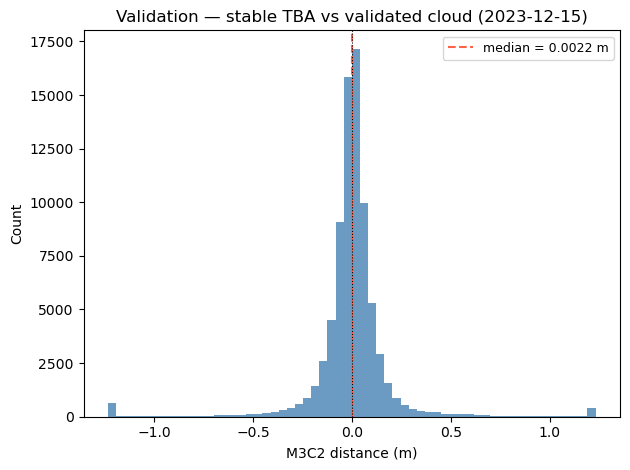

In [9]:
import py4dgeo
import matplotlib.pyplot as plt
from cntp.io import load_las, save_las, apply_glacier_mask
from cntp.coreg import extract_stable_terrain, run_m3c2

val_dir = output_dir / "output_new" / new_date / "single_day" / "validation"

# stable TBA from Step 3b — aligned_las after glacier mask + slope/NDWI filter
stable_tba_path = coreg_dir / "stable_tba" / f"{aligned_las.stem}_stable.laz"

# Extract stable terrain from the validated cloud
val_cloud = load_las(validated_laz)
val_cloud = apply_glacier_mask(val_cloud, glacier_mask)
_, val_stable = extract_stable_terrain(val_cloud)

val_stable_path = val_dir / f"{new_date}_cloud_validated_stable.laz"
save_las(val_stable, val_stable_path)
print(f"  Stable validated cloud → {val_stable_path.name}  ({len(val_stable):,} pts)")

# M3C2 between stable_tba (Step 3b) and stable validated cloud
stable_tba_cloud = load_las(stable_tba_path)
epoch_ref = py4dgeo.Epoch(stable_tba_cloud[:, :3])
epoch_val = py4dgeo.Epoch(val_stable[:, :3])

med, std, dist = run_m3c2(epoch_ref, epoch_val)
print(f"\nM3C2 median : {med:.4f} m  (near-zero → transform propagated correctly)")
print(f"M3C2 std    : {std:.4f} m")

# Plot
val_plot_dir = val_dir / "validation_plots"
val_plot_dir.mkdir(parents=True, exist_ok=True)

d = dist[~np.isnan(dist)]
clip = 3 * np.std(d)
d = np.clip(d, -clip, clip)

fig, ax = plt.subplots()
ax.hist(d, bins=60, color="steelblue", alpha=0.8)
ax.axvline(float(np.median(d)), color="tomato", linestyle="--", linewidth=1.5,
           label=f"median = {np.median(d):.4f} m")
ax.axvline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("M3C2 distance (m)")
ax.set_ylabel("Count")
ax.set_title(f"Validation — stable TBA vs validated cloud ({new_date})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(val_plot_dir / "m3c2_validation.png", dpi=150)
plt.show()

## Step 7 — Update reference registry

Appends the validated day's co-registered EOP and IOP path to `reference_registry.csv`.
The next day's run will automatically pick this up as a reference.

In [ ]:
update_registry(
    registry_csv      = registry_csv,
    date              = new_date,
    date_images       = date_images,
    cameras_coreg_csv = cameras_coreg_csv,
    calib_dir         = calib_4dsfm_dir,
)

print(f"\nRegistry : {registry_csv}")
pd.read_csv(registry_csv).groupby("date").size().reset_index(name="n_images")